**Section A:** K-means clustering

**Summary:**
*   Load df_final.csv
*   Feature selection: [log_qty_5yr, log_tds, ts_trend_norm, ts_volatility_norm]
*   Handle infinities, drop NaN
Feature scaling
*   K-means with n_clusters=4, random_state=42
*   Assign labels back to df
Save data/processed/nm_pw_clusters.csv — canonical clustering
*   Cluster profile heatmap
*   Back-transform log features to real units (qty_5yr_real, tds_real)
*   Real-number cluster means table
*  Cluster counts and percentages












This clustering analysis part takes raw data, processes it, groups similar data points using K-Means, and then provides various visualizations and statistical summaries to help understand the characteristics of each identified group.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/pw_analysis" # path in google drive in terms of colab notebooks
os.chdir(BASE_PATH)

print("Current path:", os.getcwd())

In [ ]:
import pandas as pd
import geopandas as gpd

file_path = '/content/drive/MyDrive/pw_analysis/data_clean/df_final_clean.csv' 

try:
    df_final = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}.")
    display(df_final.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

In [4]:
df_final.shape # should be (254, 16)

(254, 16)

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

Scaling Features: It uses StandardScaler to scale these features. Scaling is crucial for K-Means as it ensures that features with larger values do not disproportionately influence the clustering results.

Applying K-Means: It applies the K-Means clustering algorithm with n_clusters=4 (meaning it tries to find 4 distinct groups). The fit_predict method performs both fitting the model to the data and assigning each data point to a cluster. These cluster labels are then added back to the original df_final DataFrame.

In [6]:
features = df_final[[
    "log_qty_5yr",
    "log_tds",
    "ts_trend_norm",
    "ts_volatility_norm"
]].copy()

features = features.replace([np.inf, -np.inf], np.nan).dropna()

# Scale to zero mean / unit variance
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# KMeans on the scaled data
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(features_scaled)

# Assign back to df_final
cluster_series = pd.Series(cluster_labels, index=features.index)
df_final['cluster'] = cluster_series

**Cluster Analysis and Visualization**
1. Pair Plot: This generates a grid of scatter plots for all pairs of the selected features, colored by the assigned cluster. This helps visualize the relationships between features within each cluster and how well the clusters are separated.
2. PCA Scatter Plot: Principal Component Analysis (PCA) is used to reduce the dimensionality of the data to 2 components (PC1 and PC2). A scatter plot of these components is then generated, colored by cluster, to help visualize the clusters in a lower-dimensional space. The percentage of variance explained by each principal component is also shown.
3. Cluster Profiles Heatmap: This section calculates the mean values of the original (unscaled) features for each cluster. It then normalizes these means (z-scores) and visualizes them using a heatmap. This provides a clear, quantitative way to understand the distinguishing characteristics of each cluster (e.g., Cluster 0 has high 'log_qty_5yr', while Cluster 1 has high 'ts_volatility_norm').

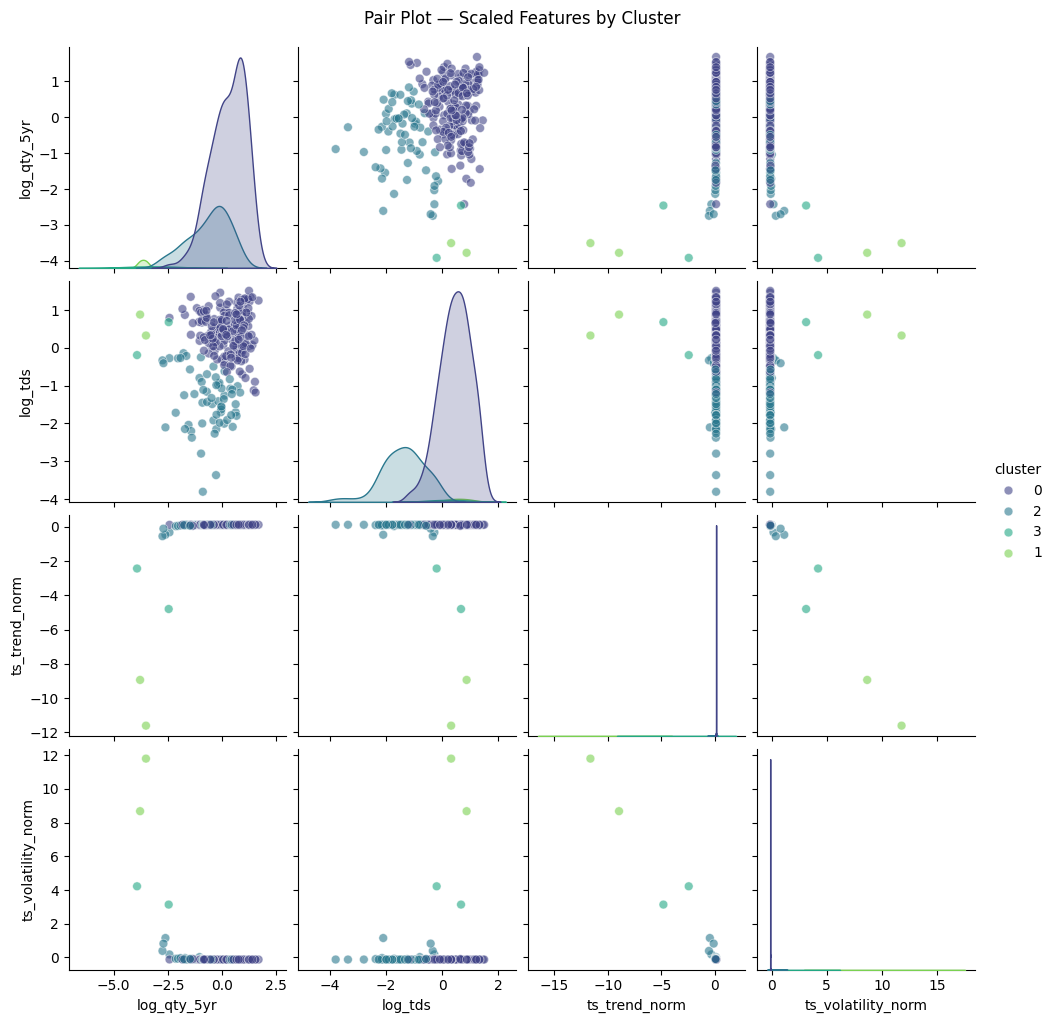

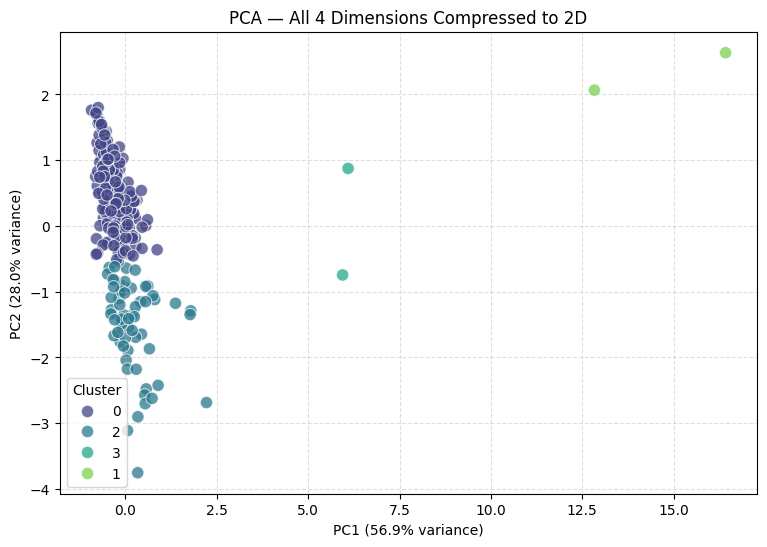

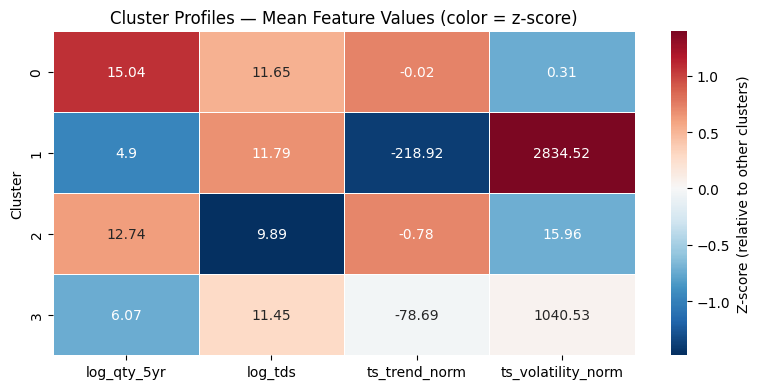

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

# prep: attach cluster labels to the scaled feature df
df_plot = pd.DataFrame(features_scaled,
                       columns=["log_qty_5yr", "log_tds", "ts_trend_norm", "ts_volatility_norm"],
                       index=features.index)
df_plot["cluster"] = cluster_series.astype(str)


# PAIR PLOT
sns.pairplot(df_plot, vars=["log_qty_5yr", "log_tds", "ts_trend_norm", "ts_volatility_norm"],
             hue="cluster", palette="viridis", plot_kws={"alpha": 0.6, "s": 40})
plt.suptitle("Pair Plot — Scaled Features by Cluster", y=1.02)
plt.show()


# PCA SCATTER
pca = PCA(n_components=2)
coords = pca.fit_transform(features_scaled)
var_explained = pca.explained_variance_ratio_ * 100

df_pca = pd.DataFrame({"PC1": coords[:, 0], "PC2": coords[:, 1],
                        "cluster": cluster_series.astype(str).values})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster",
                palette="viridis", s=80, alpha=0.75)
plt.title("PCA — All 4 Dimensions Compressed to 2D")
plt.xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# 3. CLUSTER MEANS HEATMAP
# Use ORIGINAL (unscaled) values for readability
df_orig = features.copy()
df_orig["cluster"] = cluster_series

means = df_orig.groupby("cluster")[["log_qty_5yr", "log_tds",
                                     "ts_trend_norm", "ts_volatility_norm"]].mean()

# Z-score the means so colors are comparable across features
means_z = (means - means.mean()) / means.std()

plt.figure(figsize=(8, 4))
sns.heatmap(means_z, annot=means.round(2), fmt="g",
            cmap="RdBu_r", center=0, linewidths=0.5,
            cbar_kws={"label": "Z-score (relative to other clusters)"})
plt.title("Cluster Profiles — Mean Feature Values (color = z-score)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


4. Converting Log Features to Real Numbers: The log_qty_5yr and log_tds features, which were log-transformed, are converted back to their original scale (qty_5yr_real, tds_real). This makes the interpretation of the cluster means more intuitive, as they are now in their original units (barrels and mg/L).
5. Displaying Real-Number Cluster Means: The mean values of the features for each cluster are displayed in their original units, formatted for readability, providing a summary of each cluster's typical profile.
6. Cluster Counts: Finally, it calculates and displays the number of data points (townships, in this context) in each cluster, along with their percentage of the total dataset. This gives an idea of the size and distribution of the identified clusters.

In [8]:
# CONVERT LOG FEATURES BACK TO REAL NUMBERS
df_final["qty_5yr_real"]  = np.expm1(df_final["log_qty_5yr"])  # reverses log1p
df_final["tds_real"]      = np.expm1(df_final["log_tds"])

# CLUSTER MEANS IN REAL NUMBERS
real_means = df_final.groupby("cluster")[[
    "qty_5yr_real",
    "tds_real",
    "ts_trend_norm",
    "ts_volatility_norm"
]].mean()

real_means["qty_5yr_real"]  = real_means["qty_5yr_real"].map("{:,.0f} bbl".format)
real_means["tds_real"]      = real_means["tds_real"].map("{:,.0f} mg/L".format)
real_means["ts_trend_norm"] = real_means["ts_trend_norm"].map("{:.2f}".format)
real_means["ts_volatility_norm"] = real_means["ts_volatility_norm"].map("{:.2f}".format)

real_means.columns = ["5yr Volume", "Avg TDS", "Trend (normalized)", "Volatility (normalized)"]
display(real_means)

,5yr Volume,Avg TDS,Trend (normalized),Volatility (normalized)
cluster,,,,
0.0,"12,784,134 bbl","130,932 mg/L",-0.02,0.31
1.0,142 bbl,"136,511 mg/L",-218.92,2834.52
2.0,"1,817,699 bbl","24,715 mg/L",-0.78,15.96
3.0,"1,460 bbl","101,842 mg/L",-78.69,1040.53


In [9]:
df_final['cluster'] = cluster_series
cluster_counts = df_final['cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'Number of Townships']
cluster_counts['% of Total'] = (cluster_counts['Number of Townships'] / len(df_final) * 100).round(1).astype(str) + '%'
display(cluster_counts)

,Cluster,Number of Townships,% of Total
0,0.0,182,71.7%
1,1.0,2,0.8%
2,2.0,62,24.4%
3,3.0,2,0.8%


**Section B:** Internal cluster metrics

1.   Compute silhouette (0.396), Davies-Bouldin (0.796), Calinski-Harabasz (178.4)
2.   Per-cluster silhouette table
3. Count negative silhouettes (3/248 = 1.2%)
4. Save data/outputs/internal_cluster_metrics.csv, silhouette_by_cluster.csv



# **Section C:** TDS characterization





Define Working Directories

These paths are crucial for the notebook to locate and save data. Please adjust `WORK_DIR` if your project's base directory is different.

*   `WORK_DIR`: The root directory for the entire project.
*   `DATA_DIR`: Subdirectory within `WORK_DIR` where processed data is stored.
*   `OUT_DIR`: Subdirectory within `WORK_DIR` where outputs (like figures and final metrics) are saved.

**Goals:**
1. Extract tds_real column from township-level data
2. Descriptive statistics: min, max, median, mean, percentiles
3. Histogram color-coded by treatment technology bands
4. Median/mean reference lines
5. Save figures/tds_distribution_histogram.png and data/outputs/tds_statistics.csv

In [ ]:
# Define the base working directory for the project. Modify this path if your project structure is different.
WORK_DIR = "/content/drive/MyDrive/pw_analysis" #example

# Define data and output directories relative to the WORK_DIR
DATA_DIR = f"{WORK_DIR}/data_clean/data_processed"
OUT_DIR  = f"{WORK_DIR}/outputs"

print(f"Working Directory: {WORK_DIR}")
print(f"Data Directory: {DATA_DIR}")
print(f"Output Directory: {OUT_DIR}")

In [ ]:
# example
WORK_DIR = "/content/drive/MyDrive/pw_analysis"
DATA_DIR = f"{WORK_DIR}/data_clean/data_processed"
OUT_DIR = f"{WORK_DIR}/outputs"

In [12]:
# ── STEP 1: Load township-level data and aggregate to county ──────
pw = pd.read_csv(f"{DATA_DIR}/nm_cross_validation.csv")
print(f"Raw township-level file: {len(pw)} rows across "
      f"{pw['county_key'].nunique()} counties\n")

cv = (pw.groupby("county_key", as_index=False)
          .agg(total_pw_vol   = ("qty_5yr_real",  "sum"),
               swd_count      = ("swd_well_count","first"),
               oil_well_count = ("oil_well_count","first"),
               township_count = ("geo_id",        "count"),
               median_tds     = ("tds_real",      "median"),
               max_tds        = ("tds_real",      "max"))
          .sort_values("total_pw_vol", ascending=False)
          .reset_index(drop=True))
# Expected output: Raw township-level file: 254 rows across 5 counties

Raw township-level file: 254 rows across 5 counties



In [13]:
tds = pw["tds_real"].dropna()

Loaded 254 townships with TDS values
Range: 1,958 to 312,846 mg/L
  min           1,958 mg/L
  p25          43,128 mg/L
  median       91,588 mg/L
  mean        102,799 mg/L
  p75         149,346 mg/L
  p90         203,888 mg/L
  max         312,846 mg/L


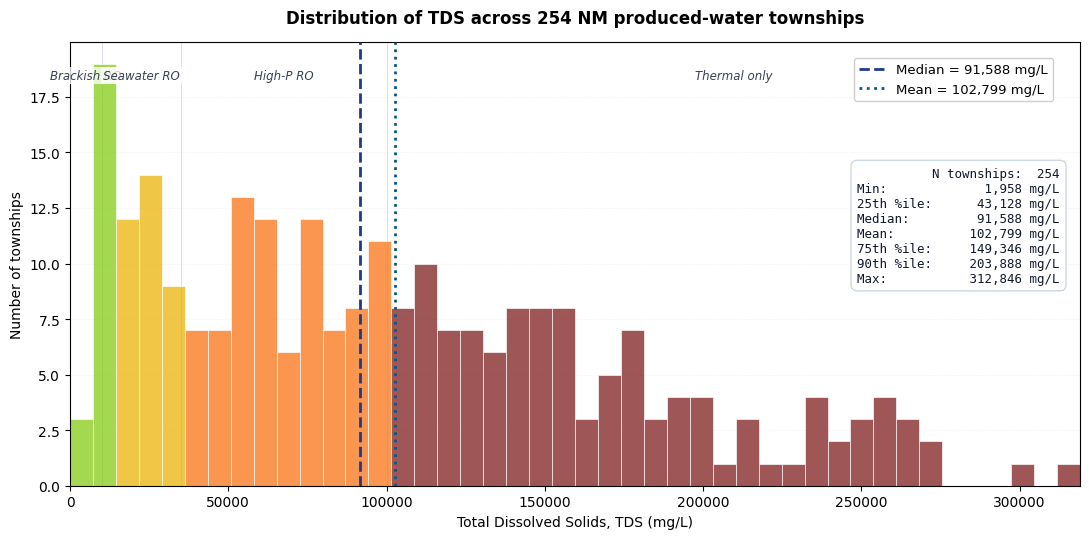


✓ Saved: tds_distribution_histogram.png
  Right-skewed distribution: mean (102,799) exceeds median (91,588)


In [14]:
print(f"Loaded {len(tds)} townships with TDS values")
print(f"Range: {tds.min():,.0f} to {tds.max():,.0f} mg/L")

# ── Compute reference statistics ──────────────────────────────────
stats_vals = {
    "min":    tds.min(),
    "p25":    tds.quantile(0.25),
    "median": tds.median(),
    "mean":   tds.mean(),
    "p75":    tds.quantile(0.75),
    "p90":    tds.quantile(0.90),
    "max":    tds.max(),
}
for k, v in stats_vals.items():
    print(f"  {k:8} {v:>10,.0f} mg/L")

# ── Figure ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))

# Histogram in mg/L units
bins = np.linspace(0, tds.max() * 1.02, 45)

n, bins_used, patches = ax.hist(tds, bins=bins,
                                 color="#F43F5E", alpha=0.82,
                                 edgecolor="white", linewidth=0.6,
                                 zorder=2)

# Color-code bars by treatment-technology band
# < 10000: brackish RO, 10000-35000: seawater RO, 35000-100000: high-P RO, >100000: thermal
tech_colors = {
    (0,     10000):  ("#84cc16", "Brackish RO"),
    (10000, 35000):  ("#eab308", "Seawater RO"),
    (35000, 100000): ("#f97316", "High-P RO"),
    (100000, 999000): ("#7f1d1d", "Thermal only"),
}

for patch, edge_low in zip(patches, bins_used[:-1]):
    for (low, high), (color, _) in tech_colors.items():
        if low <= edge_low < high:
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
            break

# ── Reference lines: median and mean ──────────────────────────────
ax.axvline(stats_vals["median"], color="#1e3a8a",
           linestyle="--", linewidth=2, zorder=4,
           label=f"Median = {stats_vals['median']:,.0f} mg/L")
ax.axvline(stats_vals["mean"], color="#065A82",
           linestyle=":",  linewidth=2, zorder=4,
           label=f"Mean = {stats_vals['mean']:,.0f} mg/L")

# ── Treatment threshold shading in the background ─────────────────
ymax = ax.get_ylim()[1]
threshold_labels = [(0, 10000, "Brackish RO"),
                    (10000, 35000, "Seawater RO"),
                    (35000, 100000, "High-P RO"),
                    (100000, tds.max()*1.02, "Thermal only")]

for low, high, label in threshold_labels:
    ax.axvline(low, color="#94a3b8", linestyle="-", linewidth=0.4,
               alpha=0.6, zorder=1)
    # Label at top of each band
    ax.text((low + min(high, tds.max()*1.02)) / 2, ymax * 0.94,
            label, ha="center", va="top", fontsize=8.5,
            color="#374151", style="italic",
            bbox=dict(facecolor="white", edgecolor="none",
                     alpha=0.75, pad=1.5))

# ── Statistics text box ───────────────────────────────────────────
stats_text = (f"N townships:  {len(tds)}\n"
              f"Min:          {stats_vals['min']:>8,.0f} mg/L\n"
              f"25th %ile:    {stats_vals['p25']:>8,.0f} mg/L\n"
              f"Median:       {stats_vals['median']:>8,.0f} mg/L\n"
              f"Mean:         {stats_vals['mean']:>8,.0f} mg/L\n"
              f"75th %ile:    {stats_vals['p75']:>8,.0f} mg/L\n"
              f"90th %ile:    {stats_vals['p90']:>8,.0f} mg/L\n"
              f"Max:          {stats_vals['max']:>8,.0f} mg/L")
ax.text(0.98, 0.72, stats_text,
        transform=ax.transAxes, fontsize=9, color="#0f172a",
        family="monospace", verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(facecolor="white", edgecolor="#CBD5E1",
                 boxstyle="round,pad=0.5", alpha=0.95))

# ── Axes and title ────────────────────────────────────────────────
ax.set_xlabel("Total Dissolved Solids, TDS (mg/L)", fontsize=10)
ax.set_ylabel("Number of townships", fontsize=10)
ax.set_title("Distribution of TDS across 254 NM produced-water townships",
             fontsize=12, fontweight="bold", pad=14)

ax.legend(loc="upper right", fontsize=9.5, framealpha=0.95,
          bbox_to_anchor=(0.98, 0.98))
ax.grid(alpha=0.25, axis="y", linestyle=":", linewidth=0.5)
ax.set_axisbelow(True)
ax.set_xlim(0, tds.max() * 1.02)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/tds_distribution_histogram.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n✓ Saved: tds_distribution_histogram.png")
print(f"  Right-skewed distribution: mean ({stats_vals['mean']:,.0f}) "
      f"exceeds median ({stats_vals['median']:,.0f})")

# **Section D:** SWD county summary

1. Pivot SWD counts by county and disposal type
2. Total disposal wells per county
3. Save data/processed/nm_swd_per_county.geojson, nm_swd_summary.csv

In [ ]:
file_path = '/content/drive/MyDrive/pw_analysis/data_raw/OCD_wells_data.csv'

try:
    df = pd.read_csv(file_path)
    # Convert DataFrame to GeoDataFrame
    geometry = gpd.points_from_xy(df['longitude'], df['latitude'])
    df = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    print(f"Successfully loaded data from {file_path}.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

In [16]:
print(df.columns.tolist())

['OBJECTID', 'id', 'name', 'type', 'status', 'sub_type_code', 'ogrid', 'ogrid_name', 'district_code', 'district', 'county_code', 'county', 'ulstr', 'latitude', 'longitude', 'projection', 'directional_status', 'details', 'files', 'year_spudded', 'lease_type', 'measured_vertical_depth', 'true_vertical_depth', 'pool_id_list', 'last_production_date', 'plug_date', 'GlobalID', 'geometry']
